# Imports

In [1]:
from Evaluator import *
from ImageProcessor import *
from LabelMapper import *
from Predictor import *
from RuralDataset import *
from SegmentationModel import *
from Trainer import *

from segmentation_models_pytorch.losses import DiceLoss, FocalLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import random_split, Subset, DataLoader
import torch

torch.cuda.empty_cache()

# HyperParameters setting

In [2]:
DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.0001
NUM_EPOCHS = 5
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Cuda device setting

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Dataset Augmentation

In [4]:
# Define Albumentations transformations
train_albumentations_transform = A.Compose([
    A.RandomResizedCrop(size=(544, 544), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Affine(translate_percent=(0.05, 0.05), scale=(0.95, 1.05), shear=5, p=0.5),
    A.Perspective(scale=(0.01, 0.1), p=0.3),
    A.GaussianBlur(blur_limit=5, sigma_limit=(0.1, 2.0), p=0.5),
    A.Resize(height=544, width=544),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_albumentations_transform = A.Compose([
    A.Resize(height=544, width=544),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

# Dataset Train and Validation split

In [5]:
# Dataset completo con augmentazione (ogni immagine originale ha 2 campioni: originale + augmentata)
full_train_augmented_dataset = RuralDataset(root_dir=DATA_ROOT, transform=train_albumentations_transform, augment=True)

# Dataset originale senza augmentazioni (solo per calcolare split)
original_dataset = RuralDataset(root_dir=DATA_ROOT, transform=None, augment=False)
train_size = int(0.8 * len(original_dataset))  # es. 744
val_size = len(original_dataset) - train_size  # es. 187

# Divido gli indici del dataset originale in train/val
train_indices, val_indices = random_split(range(len(original_dataset)), [train_size, val_size])

# Ora per ogni indice i dell'originale prendo due campioni nell'augmented dataset: i*2 e i*2+1
expanded_train_indices = []
for idx in train_indices:
    base = idx * 3
    expanded_train_indices.extend([base + i for i in range(3)])

train_dataset = Subset(full_train_augmented_dataset, expanded_train_indices)

val_dataset_full = RuralDataset(root_dir=DATA_ROOT, transform=val_albumentations_transform, augment=False)
val_dataset = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=True, pin_memory=True)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False, pin_memory=True)

print(f"Training on {len(train_loader.dataset)} samples, validating on {len(val_loader.dataset)} samples.")

Training on 2082 samples, validating on 174 samples.


# Model initialization

In [6]:
model = SegmentationModel()
model.to(device)

print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(

# Loss function and Optimizer initialization

In [7]:
focal_loss = FocalLoss(mode='multiclass', gamma=3.0)
dice_loss = DiceLoss(mode='multiclass')

def combined_loss(pred, target):
    return 0.2*(focal_loss(pred, target)) + 0.8*(dice_loss(pred, target))

criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training / Validation loop


Starting training...

Epoch 1/5


Training: 100%|██████████| 521/521 [00:29<00:00, 17.49it/s, loss=0.3714]


Train Loss: 0.4175


Validation: 100%|██████████| 44/44 [00:05<00:00,  8.16it/s, loss=0.3896]


IoU medio per classe (validation): ['0.8646', '0.5697', '0.6095', '0.4914', '0.7371', '0.2908', '0.0000', '0.3187']
Validation mIoU: 0.4852, Validation Loss: 0.3601
Nuovo modello migliore salvato in saved_model.pth

Epoch 2/5


...

IoU medio per classe (validation): ['0.8802', '0.6118', '0.6482', '0.5824', '0.8016', '0.4573', '0.3759', '0.4502']
Validation mIoU: 0.6009, Validation Loss: 0.2870
Nessun miglioramento per 1 epoche.

Epoch 5/5


Training: 100%|██████████| 521/521 [00:29<00:00, 17.79it/s, loss=0.1757]


Train Loss: 0.2423


Validation: 100%|██████████| 44/44 [00:05<00:00,  8.24it/s, loss=0.5198]


IoU medio per classe (validation): ['0.8834', '0.5878', '0.6312', '0.6073', '0.7894', '0.4560', '0.4786', '0.5718']
Validation mIoU: 0.6257, Validation Loss: 0.2833
Nuovo modello migliore salvato in saved_model.pth
Modello migliore (mIoU=0.6257) salvato in saved_model.pth


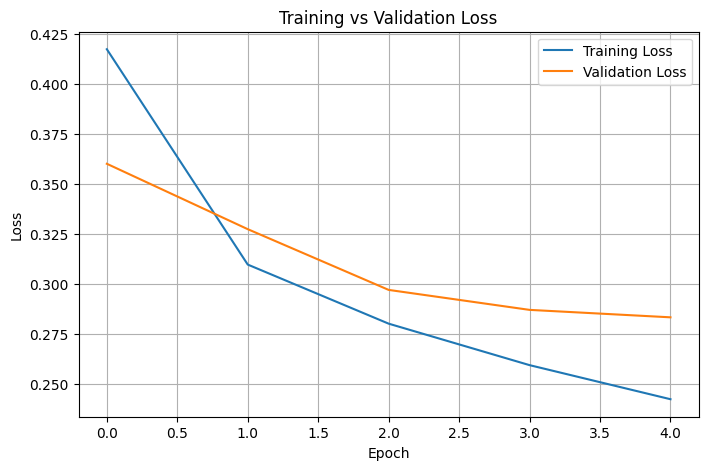

Training finished.


In [8]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

# Model loading

In [9]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.to(device)

SegmentationModel(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResidual(
        (block): Sequential(
          (0): Conv

# Evaluation of the model

In [10]:
evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()
print(metrics)

{'accuracy': 0.8062227030137613, 'precision': 0.7602344245471613, 'recall': 0.787736074579647, 'f1': 0.7658917004461391}


# Testing

In [11]:
processor = ImageProcessor()
label_mapper = LabelMapper()

def predict(model, image_numpy):
    import torch
    from PIL import Image
    import numpy as np
    from torchvision import transforms
    model.eval()
    with torch.no_grad():
        image_pil = Image.fromarray(image_numpy).convert("RGB")
        val_transform = transforms.Compose([
            transforms.Resize((272, 512)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image_tensor = val_transform(image_pil).unsqueeze(0).to(model.device if hasattr(model, 'device') else 'cpu')
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8)).resize((1024, 544), resample=Image.NEAREST))
    return pred_mask_resized


import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Metrics
def compute_iou(mask1, mask2, label):
  intersection = np.sum((mask1 == label) & (mask2 == label))
  union = np.sum((mask1 == label) | (mask2 == label))
  if union == 0:
    return np.nan
  return intersection / union
def compute_all_iou(mask1, mask2, num_labels=8):
  iou_scores = np.zeros((num_labels))
  for label in range(num_labels):
    iou = compute_iou(mask1, mask2, label+1) # we skip the background label
    iou_scores[label] = iou
  return iou_scores


# Run YOUR LOAD_MODEL FUNCTION
model = SegmentationModel(NUM_CLASSES) # Create an instance of your model class
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Main loop
test_dir = "test"  # we will change this path with that of the private test set directory
samples = os.listdir(test_dir)
IOUs = np.zeros((len(samples), 8))
verbose = False

for i, subdir in tqdm(enumerate(samples), desc="Processing samples"):
    subdir_path = os.path.join(test_dir, subdir)

    if os.path.isdir(subdir_path):
        # Get the data paths
        rgb_path = os.path.join(subdir_path, 'rgb.jpg')
        labels_path = os.path.join(subdir_path, 'labels.png')

        if os.path.exists(rgb_path) and os.path.exists(labels_path):
            if verbose:
                print(f"Processing subdirectory: {subdir}")

            try:  # ATTENTION: any error occurring in this try-catch means that the corresponding IOUs are evaluated as ZERO

                # Open images
                rgb_image = Image.open(rgb_path)
                rgb_array = np.asarray(rgb_image).copy()
                labels_image = Image.open(labels_path).convert("RGB")
                labels_array = label_mapper.color_to_class_id(labels_image).numpy()

                if verbose:
                    print(f"  Loaded {rgb_path} and {labels_path}")

                # Run YOUR PREDICT FUNCTION
                predicted_labels_array = predict(model, rgb_array)

                # Evaluate the IOU metric
                IOUs[i,:] = compute_all_iou(labels_array, predicted_labels_array)

                if verbose:
                    labels_vals = np.unique(np.asarray(labels_image))
                    print(f"  Unique labels values: {labels_vals}")
                    predicted_labels_vals = np.unique(np.asarray(predicted_labels_array))
                    print(f"  Unique predicted labels values: {predicted_labels_vals}")

                    plt.subplot(1, 3, 1)
                    plt.imshow(rgb_image)
                    plt.subplot(1, 3, 2)
                    plt.imshow(labels_image)
                    plt.subplot(1, 3, 3)
                    plt.imshow(predicted_labels_array)
                    plt.show()

                rgb_image.close()
                labels_image.close()

            except FileNotFoundError:
                print(f"  Error: Could not find image files in {subdir_path}")
            except Exception as e:
                print(f"  Error processing images in {subdir_path}: {e}")
        else:
            print(f"  Skipping subdirectory {subdir}: rgb.jpg or labels.png not found.")

score = np.nanmean(IOUs)
print(f"\nFinal competition score: {score}")

Processing samples: 145it [00:18,  7.67it/s]


Final competition score: 0.4306776914818457
